In [1]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import os
from dotenv import load_dotenv

load_dotenv()

url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"), 
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(url)

with engine.connect() as conn:
    print("Connected successfully!")

Connected successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
query = """
SELECT *
FROM features.product_features
"""

product_df = pd.read_sql(query, engine)

product_df.shape

(49677, 12)

In [4]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49677 entries, 0 to 49676
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         49677 non-null  int64  
 1   product_name       49677 non-null  object 
 2   department         49677 non-null  object 
 3   aisle              49677 non-null  object 
 4   purchase_count     49677 non-null  int64  
 5   unique_customers   49677 non-null  int64  
 6   unique_orders      49677 non-null  int64  
 7   reorder_rate       49677 non-null  float64
 8   total_reorders     49677 non-null  int64  
 9   avg_cart_position  49677 non-null  float64
 10  std_cart_position  49546 non-null  float64
 11  avg_purchase_hour  49677 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 4.5+ MB


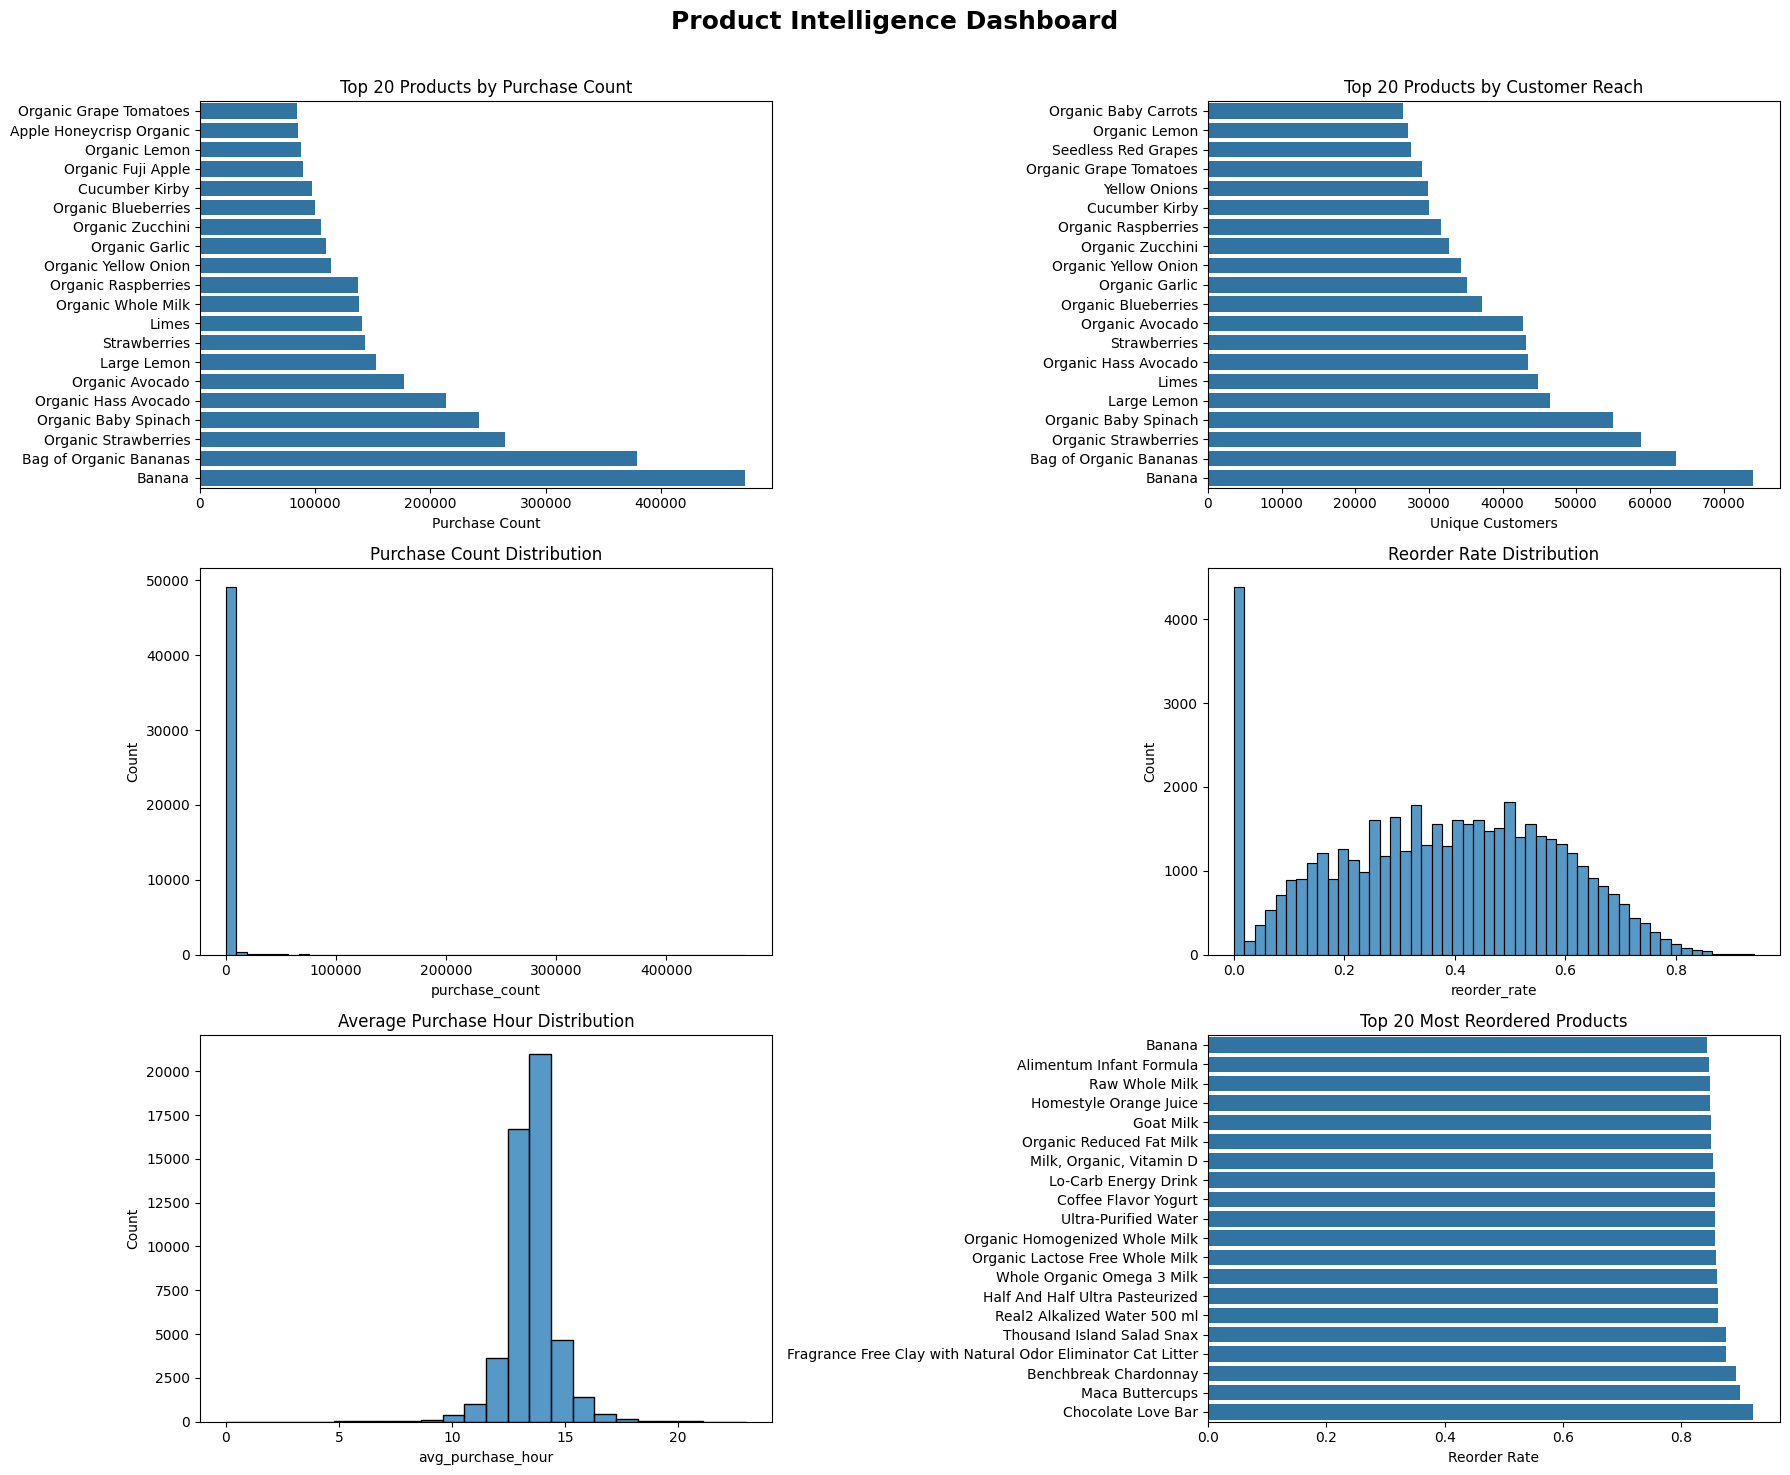

In [5]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(18, 15)
)

axes = axes.flatten()

# ---------------------------------------
# 1. Top Products by Purchase Count
# ---------------------------------------

top_products = (
    product_df
    .nlargest(20, "purchase_count")
    .sort_values("purchase_count", ascending=True)
)

sns.barplot(
    data=top_products,
    x="purchase_count",
    y="product_name",
    ax=axes[0]
)

axes[0].set_title("Top 20 Products by Purchase Count")
axes[0].set_xlabel("Purchase Count")
axes[0].set_ylabel("")

# ---------------------------------------
# 2. Top Products by Unique Customers
# ---------------------------------------

top_customers = (
    product_df
    .nlargest(20, "unique_customers")
    .sort_values("unique_customers", ascending=True)
)

sns.barplot(
    data=top_customers,
    x="unique_customers",
    y="product_name",
    ax=axes[1]
)

axes[1].set_title("Top 20 Products by Customer Reach")
axes[1].set_xlabel("Unique Customers")
axes[1].set_ylabel("")

# ---------------------------------------
# 3. Purchase Count Distribution
# ---------------------------------------

sns.histplot(
    product_df["purchase_count"],
    bins=50,
    ax=axes[2]
)

axes[2].set_title("Purchase Count Distribution")

# ---------------------------------------
# 4. Reorder Rate Distribution
# ---------------------------------------

sns.histplot(
    product_df["reorder_rate"],
    bins=50,
    ax=axes[3]
)

axes[3].set_title("Reorder Rate Distribution")

# ---------------------------------------
# 5. Average Purchase Hour Distribution
# ---------------------------------------

sns.histplot(
    product_df["avg_purchase_hour"],
    bins=24,
    ax=axes[4]
)

axes[4].set_title("Average Purchase Hour Distribution")

# ---------------------------------------
# 6. Top Products by Reorder Rate
# (minimum purchase threshold)
# ---------------------------------------

reorder_leaders = (
    product_df[product_df["purchase_count"] >= 100]
    .nlargest(20, "reorder_rate")
    .sort_values("reorder_rate", ascending=True)
)

sns.barplot(
    data=reorder_leaders,
    x="reorder_rate",
    y="product_name",
    ax=axes[5]
)

axes[5].set_title("Top 20 Most Reordered Products")
axes[5].set_xlabel("Reorder Rate")
axes[5].set_ylabel("")

# ---------------------------------------
# Layout
# ---------------------------------------

plt.suptitle(
    "Product Intelligence Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

# Product Intelligence Analysis

The Product Intelligence Dashboard provides insights into product popularity, customer reach, reorder behavior, and purchasing patterns across 49,677 products.

---

## 1. Top Products by Purchase Count

The most frequently purchased products are dominated by fresh produce and grocery staples.

### Top Products

- Banana
- Bag of Organic Bananas
- Organic Strawberries
- Organic Baby Spinach
- Organic Hass Avocado

### Key Insights

- Fresh fruits and vegetables dominate overall purchase volume.
- Organic products appear prominently among the most purchased items.
- A relatively small set of products drives a large portion of total transactions.

### Business Implications

- High-volume products require careful inventory management.
- Stockouts for these products would significantly impact customer experience.
- These products can serve as anchor items for recommendation systems.

---

## 2. Top Products by Customer Reach

Customer reach measures the number of unique customers purchasing a product.

### Key Insights

- Bananas have the largest customer reach.
- Organic produce dominates the highest-reach products.
- Popular products tend to appeal to a broad customer base rather than niche segments.

### Business Implications

- These products represent "gateway products" that attract and retain customers.
- Broadly purchased products provide excellent opportunities for cross-selling and bundle recommendations.

---

## 3. Purchase Count Distribution

The purchase count distribution exhibits an extreme long-tail pattern.

### Key Insights

- Most products are purchased relatively infrequently.
- A small number of products account for a disproportionately large share of purchases.
- Product popularity follows a power-law distribution commonly observed in retail and e-commerce.

### Business Implications

- Inventory optimization should prioritize high-volume products.
- Recommendation systems should balance popular products with long-tail discovery.
- Long-tail products contribute significantly to catalog diversity.

---

## 4. Reorder Rate Distribution

Reorder rates are distributed across a wide range of values.

### Key Insights

- Most products have moderate reorder rates.
- A significant number of products exhibit high repeat-purchase behavior.
- Some products are rarely reordered and are likely purchased occasionally or seasonally.

### Business Implications

- Reorder rate serves as a strong indicator of product stickiness.
- High-reorder products contribute heavily to customer retention.
- Products with low reorder rates may require different recommendation strategies.

---

## 5. Average Purchase Hour Distribution

Average purchase hours are concentrated within a narrow range.

### Key Insights

- Most products are purchased during daytime hours.
- Product purchasing behavior closely follows overall customer shopping activity.
- No major product groups appear to be associated with late-night purchasing.

### Business Implications

- Product demand aligns strongly with customer activity patterns.
- Marketing and promotional activities can be synchronized with peak purchasing hours.

---

## 6. Top Most Reordered Products

The highest reorder-rate products are dominated by staple grocery and household items.

### Examples

- Banana
- Milk Products
- Infant Formula
- Water Products
- Household Essentials

### Key Insights

- Frequently reordered products are primarily consumable goods.
- Customers repeatedly purchase these products as part of regular shopping routines.
- These products demonstrate exceptionally strong customer loyalty.

### Business Implications

- High-reorder products are ideal candidates for replenishment recommendations.
- Subscription and recurring-order services would be particularly effective for these products.
- Demand forecasting for these products is likely to be highly reliable.

---

# Overall Findings

The product catalog exhibits a classic e-commerce structure:

### Head Products

A small number of products generate extremely high purchase volumes and customer reach.

Examples include:

- Banana
- Bag of Organic Bananas
- Organic Strawberries
- Organic Baby Spinach

These products form the core of customer shopping baskets.

---

### Long-Tail Products

The majority of products are purchased relatively infrequently.

Although individually low-volume, these products collectively contribute to customer choice and catalog diversity.

---

### High-Loyalty Products

Products with high reorder rates demonstrate strong customer dependence and recurring demand.

These products represent the most valuable opportunities for:

- Personalized recommendations
- Subscription services
- Replenishment reminders
- Inventory planning

---

# Conclusion

The Product Intelligence analysis reveals that customer purchasing behavior is concentrated around a relatively small set of highly popular and highly reordered products, while the majority of products form a long-tail catalog. Fresh produce and grocery staples dominate both purchase volume and customer reach, highlighting their importance in customer retention and overall platform engagement.

These findings provide a strong foundation for product intelligence services, recommendation systems, demand forecasting, inventory optimization, and future GenAI-powered business insights within the CommerceAI platform.

In [6]:
df = product_df.copy()

In [7]:
print(df.sample(5))

       product_id                              product_name     department  \
38530       38538                          Sour Chewy Candy         snacks   
32336       32342   Voluminous Original Mascara - Black 305  personal care   
21753       21757                           Natural Almonds         snacks   
19725       19729  Milk Chocolate Minis Size Candy Bars Bag         snacks   
47002       47013            Gfluten Free Coconut Macaroona         bakery   

                        aisle  purchase_count  unique_customers  \
38530         candy chocolate              19                17   
32336                  beauty               4                 4   
21753  nuts seeds dried fruit             198                65   
19725         candy chocolate              27                17   
47002         bakery desserts              22                 9   

       unique_orders  reorder_rate  total_reorders  avg_cart_position  \
38530             19      0.105263               2     

In [8]:
(df["purchase_count"] == df["unique_orders"]).all()

np.True_

In [9]:
import numpy as np

df["log_purchase_count"] = np.log1p(df["purchase_count"])

df["log_purchase_count"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    49677.000000
mean         4.341086
std          1.854750
min          0.693147
25%          2.890372
50%          4.110874
75%          5.564520
90%          6.929517
95%          7.734996
99%          9.203533
max         13.065933
Name: log_purchase_count, dtype: float64

In [10]:
print("Purchase Count")
print(
    df["purchase_count"].describe(
        percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
    )
)

print("\nLog Purchase Count")
print(
    df["log_purchase_count"].describe(
        percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
    )
)

Purchase Count
count     49677.000000
mean        652.907563
std        4792.114416
min           1.000000
25%          17.000000
50%          60.000000
75%         260.000000
90%        1021.000000
95%        2286.000000
99%        9931.160000
max      472565.000000
Name: purchase_count, dtype: float64

Log Purchase Count
count    49677.000000
mean         4.341086
std          1.854750
min          0.693147
25%          2.890372
50%          4.110874
75%          5.564520
90%          6.929517
95%          7.734996
99%          9.203533
max         13.065933
Name: log_purchase_count, dtype: float64


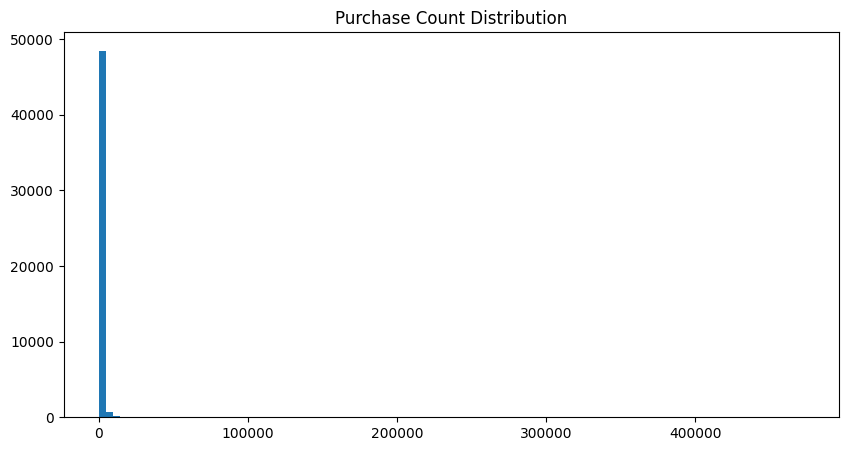

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["purchase_count"], bins=100)
plt.title("Purchase Count Distribution")
plt.show()

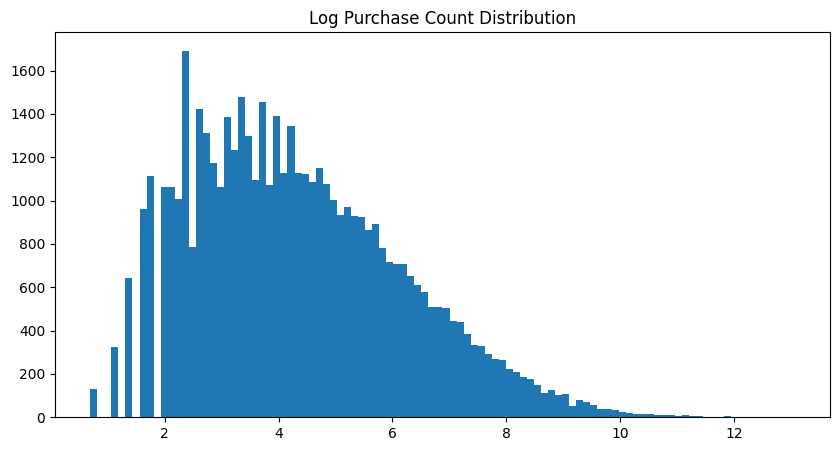

In [12]:
plt.figure(figsize=(10,5))
plt.hist(df["log_purchase_count"], bins=100)
plt.title("Log Purchase Count Distribution")
plt.show()

In [13]:
df["log_purchase_count"] = np.log1p(
    df["purchase_count"]
)

df["global_popularity_score"] = (
    df["log_purchase_count"]
    .rank(pct=True)
    * 100
)

df["department_popularity_score"] = (
    df.groupby("department")["log_purchase_count"]
      .rank(method="average", pct=True)
      * 100
)

In [14]:
df["department_popularity_score"].describe(
    percentiles=[0.25,0.5,0.75,0.9,0.95,0.99]
)

count    49677.000000
mean        50.021137
std         28.865492
min          0.064872
25%         25.118543
50%         50.060948
75%         75.026911
90%         90.018712
95%         95.013006
99%         99.018608
max        100.000000
Name: department_popularity_score, dtype: float64

In [15]:
df.sort_values(
    "global_popularity_score",
    ascending=False
)[[
    "product_name",
    "department",
    "purchase_count",
    "global_popularity_score"
]].head(20)

,product_name,department,purchase_count,global_popularity_score
24848,Banana,produce,472565,100.000000
13172,Bag of Organic Bananas,produce,379450,99.997987
21133,Organic Strawberries,produce,264683,99.995974
21899,Organic Baby Spinach,produce,241921,99.993961
47198,Organic Hass Avocado,produce,213584,99.991948
47755,Organic Avocado,produce,176815,99.989935
47615,Large Lemon,produce,152657,99.987922
16793,Strawberries,produce,142951,99.985909
26204,Limes,produce,140627,99.983896
27839,Organic Whole Milk,dairy eggs,137905,99.981883


In [16]:
df.sort_values(
    "global_popularity_score"
)[[
    "product_name",
    "department",
    "purchase_count",
    "global_popularity_score"
]].head(20)

,product_name,department,purchase_count,global_popularity_score
17581,Raspberry Blast Fruit and Chia Seed Bar,snacks,1,0.132858
45264,Flame Roasted Red Peppers Spreadable Cheese,deli,1,0.132858
39751,"Indoor & Outdoor Allergies, Allergy & Congesti...",personal care,1,0.132858
6059,Multigrain Penne Rigate,dry goods pasta,1,0.132858
30062,Dynostix Rawhide Chew With Meat,pets,1,0.132858
37081,Lndbrg White Quinoa 16 Z,missing,1,0.132858
47669,Indian Wells Merlot,alcohol,1,0.132858
46369,Skin Firming Cellulite Gel Cream,personal care,1,0.132858
4623,Master Blend Ground Coffee,missing,1,0.132858
25244,Glycerine Soap Cucumber,personal care,1,0.132858


In [17]:
df.loc[
    df["product_name"].str.contains(
        "Banana",
        case=False,
        na=False
    ),
    [
        "product_name",
        "purchase_count",
        "global_popularity_score",
        "department_popularity_score"
    ]
].head(20)

,product_name,purchase_count,global_popularity_score,department_popularity_score
62,Banana & Sweet Potato Organic Teething Wafers,1129,90.753266,89.777983
312,Peppermint/Banana Split Variety Pack Frozen Da...,8,11.675423,7.187422
425,2nd Foods Bananas,61,50.414679,45.559667
601,Banana Chocolate Chip,24,31.767216,20.277015
848,Blueberry & Banana Tiny Fruits Freeze Dried Sn...,238,73.713187,72.571693
865,Flavor & Fiber Banana Walnut Bar,69,52.877589,48.060035
910,"Protein Shake, Organic, Banana Creme",80,55.769269,50.573000
1016,Strawberry Banana Juice,1697,93.446665,92.826037
1017,Kids Organic Mashups Squeezable Fruit Strawber...,36,39.931960,35.846438
1228,Restore Banana Kale Banana & Pineapple,25,32.564366,20.813576


In [18]:
df.sort_values(
    "department_popularity_score",
    ascending=False
)[[
    "product_name",
    "department",
    "purchase_count",
    "department_popularity_score"
]].head(20)

,product_name,department,purchase_count,department_popularity_score
2119,Sauvignon Blanc,alcohol,8246,100.0
24848,Banana,produce,472565,100.0
7072,Grain Free Chicken Formula Cat Food,pets,1825,100.0
31500,Extra Virgin Olive Oil,pantry,50255,100.0
12308,Lavender Hand Soap,personal care,5941,100.0
44623,Sparkling Water Grapefruit,beverages,75886,100.0
30483,Original Hummus,deli,71314,100.0
23371,Marinara Sauce,dry goods pasta,19998,100.0
36717,Organic Sea Salt Roasted Seaweed Snacks,international,10345,100.0
43866,Baby Food Stage 2 Blueberry Pear & Purple Carrot,babies,8793,100.0


In [19]:
df["department_popularity_score"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count    49677.000000
mean        50.021137
std         28.865492
min          0.064872
25%         25.118543
50%         50.060948
75%         75.026911
90%         90.018712
95%         95.013006
99%         99.018608
max        100.000000
Name: department_popularity_score, dtype: float64

In [20]:
df[[
    "product_name",
    "department",
    "global_popularity_score",
    "department_popularity_score"
]].sort_values(
    "global_popularity_score",
    ascending=False
).head(20)

,product_name,department,global_popularity_score,department_popularity_score
24848,Banana,produce,100.000000,100.000000
13172,Bag of Organic Bananas,produce,99.997987,99.940618
21133,Organic Strawberries,produce,99.995974,99.881235
21899,Organic Baby Spinach,produce,99.993961,99.821853
47198,Organic Hass Avocado,produce,99.991948,99.762470
47755,Organic Avocado,produce,99.989935,99.703088
47615,Large Lemon,produce,99.987922,99.643705
16793,Strawberries,produce,99.985909,99.584323
26204,Limes,produce,99.983896,99.524941
27839,Organic Whole Milk,dairy eggs,99.981883,100.000000


In [21]:
print(df["reorder_rate"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
))

print(df["total_reorders"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
))

count    49677.000000
mean         0.366461
std          0.208103
min          0.000000
25%          0.208075
50%          0.376623
75%          0.529307
90%          0.634010
95%          0.688889
99%          0.772983
max          0.941176
Name: reorder_rate, dtype: float64
count     49677.000000
mean        385.017936
std        3601.713646
min           0.000000
25%           4.000000
50%          22.000000
75%         115.000000
90%         514.000000
95%        1229.000000
99%        5964.120000
max      398609.000000
Name: total_reorders, dtype: float64


In [22]:
import numpy as np

df["log_total_reorders"] = np.log1p(
    df["total_reorders"]
)

df["log_total_reorders"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count    49677.000000
mean         3.293974
std          2.153241
min          0.000000
25%          1.609438
50%          3.135494
75%          4.753590
90%          6.244167
95%          7.114769
99%          8.693684
max         12.895739
Name: log_total_reorders, dtype: float64

In [23]:
df.sort_values(
    "reorder_rate",
    ascending=False
)[[
    "product_name",
    "purchase_count",
    "reorder_rate",
    "total_reorders"
]].head(20)

,product_name,purchase_count,reorder_rate,total_reorders
6430,Raw Veggie Wrappers,68,0.941176,64
2074,Serenity Ultimate Extrema Overnight Pads,87,0.931034,81
43545,Orange Energy Shots,13,0.923077,12
27734,Chocolate Love Bar,101,0.920792,93
14605,Soy Powder Infant Formula,35,0.914286,32
13871,Simply Sleep Nighttime Sleep Aid,45,0.911111,41
39984,"Energy Shot, Grape Flavor",22,0.909091,20
31412,Sparking Water,60,0.900000,54
5865,Russian River Valley Reserve Pinot Noir,30,0.900000,27
35598,Maca Buttercups,100,0.900000,90


In [24]:
df[[
    "reorder_rate",
    "log_total_reorders"
]].corr()

,reorder_rate,log_total_reorders
reorder_rate,1.000000,0.737889
log_total_reorders,0.737889,1.000000


In [25]:
df.sort_values(
    "reorder_rate",
    ascending=False
)[[
    "product_name",
    "purchase_count",
    "reorder_rate",
    "total_reorders"
]].head(20)

,product_name,purchase_count,reorder_rate,total_reorders
6430,Raw Veggie Wrappers,68,0.941176,64
2074,Serenity Ultimate Extrema Overnight Pads,87,0.931034,81
43545,Orange Energy Shots,13,0.923077,12
27734,Chocolate Love Bar,101,0.920792,93
14605,Soy Powder Infant Formula,35,0.914286,32
13871,Simply Sleep Nighttime Sleep Aid,45,0.911111,41
39984,"Energy Shot, Grape Flavor",22,0.909091,20
31412,Sparking Water,60,0.900000,54
5865,Russian River Valley Reserve Pinot Noir,30,0.900000,27
35598,Maca Buttercups,100,0.900000,90


In [26]:
df.sort_values(
    "total_reorders",
    ascending=False
)[[
    "product_name",
    "purchase_count",
    "reorder_rate",
    "total_reorders"
]].head(20)

,product_name,purchase_count,reorder_rate,total_reorders
24848,Banana,472565,0.843501,398609
13172,Bag of Organic Bananas,379450,0.832555,315913
21133,Organic Strawberries,264683,0.777704,205845
21899,Organic Baby Spinach,241921,0.772500,186884
47198,Organic Hass Avocado,213584,0.796553,170131
47755,Organic Avocado,176815,0.758103,134044
27839,Organic Whole Milk,137905,0.830354,114510
47615,Large Lemon,152657,0.696038,106255
27960,Organic Raspberries,137057,0.769089,105409
16793,Strawberries,142951,0.698155,99802


In [27]:
global_avg_reorder_rate = (
    df["total_reorders"].sum()
    /
    df["purchase_count"].sum()
)

In [28]:
global_avg_reorder_rate

np.float64(0.5896974667922161)

In [29]:
m=100

In [30]:
df["smoothed_reorder_rate"] = (
    df["total_reorders"] +
    global_avg_reorder_rate * m
) / (
    df["purchase_count"] + m
)

In [31]:
df["smoothed_reorder_rate"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count    49677.000000
mean         0.528751
std          0.084457
min          0.083091
25%          0.490127
50%          0.544469
75%          0.572628
90%          0.612750
95%          0.650591
99%          0.725075
max          0.857295
Name: smoothed_reorder_rate, dtype: float64

In [32]:
df.sort_values(
    "smoothed_reorder_rate",
    ascending=False
)[[
    "product_name",
    "purchase_count",
    "reorder_rate",
    "smoothed_reorder_rate",
    "total_reorders"
]].head(30)

,product_name,purchase_count,reorder_rate,smoothed_reorder_rate,total_reorders
45495,Whole Organic Omega 3 Milk,9108,0.860233,0.857295,7835
43386,Organic Lactose Free Whole Milk,8477,0.859030,0.855890,7282
29441,"Milk, Organic, Vitamin D",20198,0.854342,0.853038,17256
9288,Half And Half Ultra Pasteurized,2921,0.861691,0.852688,2517
5511,Organic Homogenized Whole Milk,3970,0.857683,0.851098,3405
38681,Organic Reduced Fat Milk,35663,0.850686,0.849956,30338
34191,Goat Milk,5185,0.849952,0.845027,4407
24848,Banana,472565,0.843501,0.843447,398609
47220,Ultra-Purified Water,1489,0.857623,0.840761,1277
31714,Organic Whole Milk,9842,0.841191,0.838661,8279


In [33]:
df['loyalty_efficiency_score'] = (
    df['smoothed_reorder_rate']
    .rank(pct=True)
    * 100
)

In [34]:
df['loyalty_volume_score'] = (
    df['log_total_reorders']
    .rank(pct=True)
    * 100
)

In [35]:
df["global_loyalty_score"] = (
    df["loyalty_efficiency_score"]
    +
    df["loyalty_volume_score"]
) / 2

In [36]:
df.sort_values(
    "global_loyalty_score",
    ascending=False
)[[
    "product_name",
    "purchase_count",
    "reorder_rate",
    "smoothed_reorder_rate",
    "total_reorders",
    "global_loyalty_score"
]].head(20)

,product_name,purchase_count,reorder_rate,smoothed_reorder_rate,total_reorders,global_loyalty_score
24848,Banana,472565,0.843501,0.843447,398609,99.992954
13172,Bag of Organic Bananas,379450,0.832555,0.832491,315913,99.985909
27839,Organic Whole Milk,137905,0.830354,0.830180,114510,99.977857
47198,Organic Hass Avocado,213584,0.796553,0.796456,170131,99.936590
19656,Spring Water,56087,0.812274,0.811878,45558,99.935584
38681,Organic Reduced Fat Milk,35663,0.850686,0.849956,30338,99.929545
5782,Organic Reduced Fat 2% Milk,47839,0.805702,0.805252,38544,99.908408
21133,Organic Strawberries,264683,0.777704,0.777633,205845,99.893311
5476,Italian Sparkling Mineral Water,30937,0.813686,0.812964,25173,99.889285
49224,Organic Half & Half,76360,0.781456,0.781205,59672,99.889285


In [37]:
df["unique_customers"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count    49677.000000
mean       267.889627
std       1308.788623
min          1.000000
25%         11.000000
50%         35.000000
75%        137.000000
90%        491.000000
95%       1026.200000
99%       3891.720000
max      73956.000000
Name: unique_customers, dtype: float64

In [38]:
df["log_unique_customers"] = np.log1p(
    df["unique_customers"]
)

df["log_unique_customers"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count    49677.000000
mean         3.839740
std          1.671516
min          0.693147
25%          2.484907
50%          3.583519
75%          4.927254
90%          6.198479
95%          6.934592
99%          8.266863
max         11.211239
Name: log_unique_customers, dtype: float64

In [39]:
total_customers = 206209

In [40]:
df["customer_penetration"] = (
    df["unique_customers"]
    / total_customers
)

In [41]:
df[[
    "unique_customers",
    "customer_penetration"
]].corr()

,unique_customers,customer_penetration
unique_customers,1.0,1.0
customer_penetration,1.0,1.0


In [42]:
df["log_unique_customers"] = np.log1p(
    df["unique_customers"]
)

df["global_reach_score"] = (
    df["log_unique_customers"]
      .rank(pct=True)
      * 100
)

df["department_reach_score"] = (
    df.groupby("department")["log_unique_customers"]
      .rank(method="average", pct=True)
      * 100
)

In [43]:
df["global_reach_score"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count    49677.000000
mean        50.001007
std         28.864412
min          0.168086
25%         24.280854
50%         49.921493
75%         74.956217
90%         90.007448
95%         94.998893
99%         99.000020
max        100.000000
Name: global_reach_score, dtype: float64

In [44]:
df.sort_values(
    "global_reach_score",
    ascending=False
)[[
    "product_name",
    "department",
    "unique_customers",
    "global_reach_score"
]].head(20)

,product_name,department,unique_customers,global_reach_score
24848,Banana,produce,73956,100.000000
13172,Bag of Organic Bananas,produce,63537,99.997987
21133,Organic Strawberries,produce,58838,99.995974
21899,Organic Baby Spinach,produce,55037,99.993961
47615,Large Lemon,produce,46402,99.991948
26204,Limes,produce,44859,99.989935
47198,Organic Hass Avocado,produce,43453,99.987922
16793,Strawberries,produce,43149,99.985909
47755,Organic Avocado,produce,42771,99.983896
39267,Organic Blueberries,produce,37138,99.981883


In [45]:
df.sort_values(
    "department_reach_score",
    ascending=False
)[[
    "product_name",
    "department",
    "unique_customers",
    "department_reach_score"
]].head(20)

,product_name,department,unique_customers,department_reach_score
30483,Original Hummus,deli,19624,100.0
24848,Banana,produce,73956,100.0
41836,Honey Nut Cheerios,breakfast,11401,100.0
9072,Blueberries,frozen,23354,100.0
41141,Organic Riced Cauliflower,missing,4342,100.0
27839,Organic Whole Milk,dairy eggs,23395,100.0
2449,Taco Seasoning,international,4149,100.0
44623,Sparkling Water Grapefruit,beverages,17373,100.0
13866,Lightly Salted Baked Snap Pea Crisps,snacks,9287,100.0
49344,Instant Action Cat Litter,pets,556,100.0


In [46]:
df[[
    "global_popularity_score",
    "global_reach_score"
]].corr()

,global_popularity_score,global_reach_score
global_popularity_score,1.000000,0.982191
global_reach_score,0.982191,1.000000


In [47]:
df["reach_minus_popularity"] = (
    df["global_reach_score"]
    -
    df["global_popularity_score"]
)

df.sort_values(
    "reach_minus_popularity",
    ascending=False
)[[
    "product_name",
    "unique_customers",
    "purchase_count",
    "global_popularity_score",
    "global_reach_score",
    "reach_minus_popularity"
]].head(20)

,product_name,unique_customers,purchase_count,global_popularity_score,global_reach_score,reach_minus_popularity
784,Get Lost Weight Loss Tea,44,44,43.917708,54.732572,10.814864
14309,Natural Body Brush,44,44,43.917708,54.732572,10.814864
18263,Gel Food Colors,47,47,45.197979,56.009823,10.811845
5208,Gift Sleeve Valentine Chocolate Hearts,43,43,43.457737,54.238380,10.780643
46532,100% Cotton 16 Ply Strength 25 ft Cooking Twine,48,48,45.628762,56.406385,10.777623
24318,Round Cake Pan 9\,51,51,46.905006,57.658474,10.753467
42453,Nonpareil Decorating Decors,51,51,46.905006,57.658474,10.753467
32289,Organic Breathe Easy Rub,42,42,42.993740,53.744187,10.750448
39114,Freeze Dried Dill,42,42,42.993740,53.744187,10.750448
21402,Whole Organic Anise,50,50,46.497373,57.243795,10.746422


In [48]:
df.sort_values(
    "reach_minus_popularity"
)[[
    "product_name",
    "unique_customers",
    "purchase_count",
    "global_popularity_score",
    "global_reach_score",
    "reach_minus_popularity"
]].head(20)

,product_name,unique_customers,purchase_count,global_popularity_score,global_reach_score,reach_minus_popularity
6430,Raw Veggie Wrappers,4,68,52.569600,5.016406,-47.553194
2074,Serenity Ultimate Extrema Overnight Pads,6,87,57.222658,11.886789,-45.335870
27734,Chocolate Love Bar,8,101,59.878817,17.703364,-42.175453
13871,Simply Sleep Nighttime Sleep Aid,4,45,44.357550,5.016406,-39.341144
31412,Sparking Water,6,60,50.114741,11.886789,-38.227953
35598,Maca Buttercups,10,100,59.694627,22.223564,-37.471063
36536,Bars Peanut Butter,7,67,52.273688,15.004932,-37.268756
14605,Soy Powder Infant Formula,3,35,39.397508,2.330052,-37.067456
26088,Soy Crisps Lightly Salted,7,66,52.001932,15.004932,-36.997001
4209,High Gravity Lager,4,37,40.473459,5.016406,-35.457053


In [49]:
product_df = df

In [50]:
product_df[
    [
        "avg_cart_position",
        "std_cart_position"
    ]
].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

,avg_cart_position,std_cart_position
count,49677.000000,49546.000000
mean,9.097568,7.268825
std,2.551267,2.212218
min,1.000000,0.000000
25%,7.625850,6.132971
50%,9.057269,7.228261
75%,10.356401,8.215806
90%,11.863636,9.520755
95%,13.142857,10.757077
99%,16.756667,14.294754


In [51]:
product_df[
    [
        "avg_cart_position",
        "std_cart_position"
    ]
].corr()

,avg_cart_position,std_cart_position
avg_cart_position,1.000000,0.713765
std_cart_position,0.713765,1.000000


In [52]:
product_df["priority_score"] = (
    product_df["avg_cart_position"]
        .rank(
            pct=True,
            ascending=False
        )
    * 100
)

product_df["consistency_score"] = (
    product_df["std_cart_position"]
        .rank(
            pct=True,
            ascending=False
        )
    * 100
)

product_df["purchase_intent_score"] = (
    product_df["priority_score"]
    +
    product_df["consistency_score"]
) / 2

In [53]:
product_df.sort_values(
    "purchase_intent_score",
    ascending=False
)[[
    "product_name",
    "avg_cart_position",
    "std_cart_position",
    "purchase_intent_score"
]].head(50)

,product_name,avg_cart_position,std_cart_position,purchase_intent_score
41782,Peppermint Schnapps Liqueur,1.000000,0.000000,99.979339
2795,American Blend,1.000000,0.000000,99.979339
36590,Vanilla Flavor Multi-Symptom Relief,1.000000,0.000000,99.979339
3830,Quart Bags,1.000000,0.000000,99.979339
34956,Prenatal Nutrients,1.000000,0.000000,99.979339
12837,King Crab Legs,1.000000,0.000000,99.979339
27857,Cooking Fuel,1.000000,0.000000,99.979339
39643,Honey Lemon Flavor Oral Mist Cold Remedy,1.333333,0.577350,99.944054
32252,Family Pack Lice Killing Creme Rinse - 2 CT,1.500000,0.577350,99.937008
47512,Raspberry Cheesecake,1.500000,0.577350,99.937008


In [54]:
product_df.sort_values(
    "purchase_intent_score"
)[[
    "product_name",
    "avg_cart_position",
    "std_cart_position",
    "purchase_intent_score"
]].head(50)

,product_name,avg_cart_position,std_cart_position,purchase_intent_score
33400,Eczema Control,41.000000,29.698485,0.016136
24718,Gold Bears,28.857143,31.136413,0.027197
8647,Shipping Packaging Tape Heavy Duty,26.750000,35.836434,0.030200
43380,Organic Petite Creme Mon Cherry Amour Yogurt,27.000000,32.526912,0.030712
3829,Cranberry Ginger Fruit and Root Juice,31.000000,25.455844,0.036298
33060,Drinking Chocolate,26.000000,35.618347,0.037752
5640,Spicy Black Bean Veggie Burger,28.000000,26.870058,0.040311
45310,Original Submarine Dressing,31.833333,23.894909,0.040340
13487,Whenever Green Tea & Lime Scent Shampoo,26.000000,29.698485,0.046834
4167,"Cereal, Veganic Sprouted, Spelt Flakes",30.500000,23.334524,0.049414


In [55]:
product_df.sort_values(
    "purchase_count"
).head(20)[[
    "product_name",
    "purchase_count",
    "avg_cart_position",
    "std_cart_position"
]]

,product_name,purchase_count,avg_cart_position,std_cart_position
17581,Raspberry Blast Fruit and Chia Seed Bar,1,13.0,NaN
45264,Flame Roasted Red Peppers Spreadable Cheese,1,18.0,NaN
39751,"Indoor & Outdoor Allergies, Allergy & Congesti...",1,1.0,NaN
6059,Multigrain Penne Rigate,1,6.0,NaN
30062,Dynostix Rawhide Chew With Meat,1,8.0,NaN
37081,Lndbrg White Quinoa 16 Z,1,1.0,NaN
47669,Indian Wells Merlot,1,1.0,NaN
46369,Skin Firming Cellulite Gel Cream,1,3.0,NaN
4623,Master Blend Ground Coffee,1,4.0,NaN
25244,Glycerine Soap Cucumber,1,3.0,NaN


In [56]:
global_std_position = product_df["std_cart_position"].mean()

product_df["smoothed_std_cart_position"] = (
    (
        product_df["purchase_count"]
        * product_df["std_cart_position"].fillna(global_std_position)
    )
    +
    (
        100 * global_std_position
    )
) / (
    product_df["purchase_count"] + 100
)

In [57]:
global_avg_position = product_df["avg_cart_position"].mean()

product_df["smoothed_avg_cart_position"] = (
    (
        product_df["purchase_count"]
        * product_df["avg_cart_position"]
    )
    +
    (
        100 * global_avg_position
    )
) / (
    product_df["purchase_count"] + 100
)

In [ ]:
print("global_std_position : ",global_std_position)
print("global_avg_position :",global_avg_position)
print("global_reorder_rate :",global_reorder_rate)

global_std_position :  7.2688253370464055
global_avg_position : 9.09756808901078


In [58]:
product_df["smoothed_avg_cart_position"] = (
    (
        product_df["purchase_count"]
        * product_df["avg_cart_position"]
    )
    +
    (
        m * global_avg_position
    )
) / (
    product_df["purchase_count"] + m
)

In [59]:
product_df["priority_score"] = (
    product_df["smoothed_avg_cart_position"]
    .rank(
        pct=True,
        ascending=False
    )
    * 100
)

product_df["consistency_score"] = (
    product_df["smoothed_std_cart_position"]
    .rank(
        pct=True,
        ascending=False
    )
    * 100
)

product_df["global_purchase_intent_score"] = (
    product_df["priority_score"]
    +
    product_df["consistency_score"]
) / 2


In [60]:
product_df.sort_values(
    "global_purchase_intent_score",
    ascending=False
)[[
    "product_name",
    "purchase_count",
    "avg_cart_position",
    "smoothed_avg_cart_position",
    "std_cart_position",
    "smoothed_std_cart_position",
    "global_purchase_intent_score"
]].head(50)

,product_name,purchase_count,avg_cart_position,smoothed_avg_cart_position,std_cart_position,smoothed_std_cart_position,global_purchase_intent_score
20936,Organic Low Fat Milk,8438,2.881251,2.954059,2.804630,2.856916,99.996980
26895,USDA AA Extra Large Eggs,2231,3.012999,3.274027,2.532358,2.735552,99.996980
46139,Zero Calorie Cola,8558,3.176910,3.245294,2.761531,2.813591,99.996980
31645,Extra Fancy Unsalted Mixed Nuts,9709,3.283757,3.343028,2.811208,2.856652,99.990941
8567,Baby Cucumbers,14399,3.448642,3.487603,2.928463,2.958399,99.984902
22798,Mineral Water,5936,3.191712,3.289555,3.185737,3.253382,99.982889
13255,Organic Variety Pack,3097,3.372942,3.552004,2.771688,2.912355,99.981883
35464,Water Mineral,2244,2.688948,2.962354,3.155707,3.331181,99.981883
35263,Vegetable Tray With Low Fat Dressing,2752,3.298692,3.502019,2.959712,3.110803,99.980876
38920,0% Greek Strained Yogurt,13238,3.487309,3.529371,3.133495,3.164500,99.978863


In [61]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49677 entries, 0 to 49676
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   product_id                    49677 non-null  int64  
 1   product_name                  49677 non-null  object 
 2   department                    49677 non-null  object 
 3   aisle                         49677 non-null  object 
 4   purchase_count                49677 non-null  int64  
 5   unique_customers              49677 non-null  int64  
 6   unique_orders                 49677 non-null  int64  
 7   reorder_rate                  49677 non-null  float64
 8   total_reorders                49677 non-null  int64  
 9   avg_cart_position             49677 non-null  float64
 10  std_cart_position             49546 non-null  float64
 11  avg_purchase_hour             49677 non-null  float64
 12  log_purchase_count            49677 non-null  float64
 13  g

In [62]:
product_df["department_loyalty_score"] = (
    product_df.groupby("department")["global_loyalty_score"]
              .rank(pct=True)
              * 100
)

In [63]:
product_df["department_purchase_intent_score"] = (
    product_df.groupby("department")["global_purchase_intent_score"]
              .rank(pct=True)
              * 100
)